Задание 1: Влияние параметра Alpha
Цель: Понять, как сила регуляризации влияет на веса модели. Инструкция:

Используйте датасет fetch_california_housing из sklearn.datasets.
Разделите данные на train/test.
Обучите модель Ridge на стандартных данных (без полиномов, только масштабирование).
Переберите значения alpha от 0.01 до 1000 (логарифмическая шкала).
Постройте график: по оси X — log(alpha), по оси Y — величина коэффициентов (весов) модели. Вопрос: Что происходит с весами при увеличении alpha?
Подсказка: Используйте RidgeCV или цикл for. Для визуализации весов используйте model.coef_.

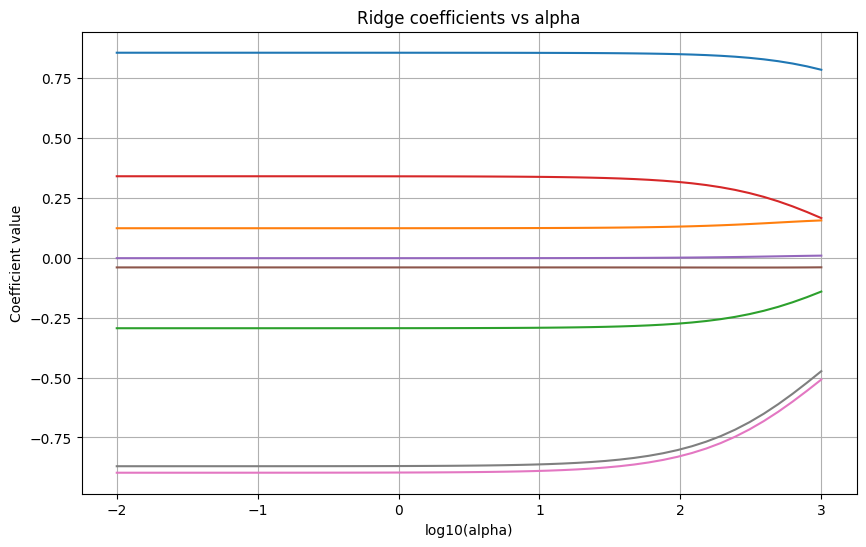

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Загрузка данных
data = fetch_california_housing()
X = data.data
y = data.target

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Масштабирование данных (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Значения параметра alpha (логарифмическая шкала)
alphas = np.logspace(-2, 3, 50)

# Сохранение коэффициентов модели
coefs = []

# Обучение модели для каждого значения α
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    coefs.append(model.coef_)

coefs = np.array(coefs)

# Построение графика
plt.figure(figsize=(10,6))

for i in range(coefs.shape[1]):
    plt.plot(np.log10(alphas), coefs[:, i])

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficients vs alpha")
plt.grid(True)

plt.show()

При увеличении значения параметра alpha в модели Ridge:

коэффициенты начинают сжиматься к нулю (shrinkage);

кривые на графике становятся более сглаженными и постепенно приближаются к нулевой линии;

модель становится менее чувствительной к шуму и приобретает более простую структуру;

при слишком больших значениях alpha модель становится чрезмерно упрощённой, что может привести к недообучению (underfitting).

Задание 2: Lasso как отбор признаков
Цель: Убедиться в свойстве разреженности Lasso. Инструкция:

Создайте синтетические данные с помощью make_regression, где n_features=20, но только 5 из них информативны (n_informative=5).
Обучите Lasso с небольшим alpha (например, 0.01) и с большим (например, 1.0).
Посчитайте количество коэффициентов, которые стали ровно нулеми (или близки к нулю, например < 0.0001).
Сравните с Ridge на тех же данных. Вопрос: Какая модель обнулила больше весов? Помогло ли это выявить информативные признаки?
Подсказка: Используйте np.sum(np.abs(model.coef_) < 1e-5).

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Генерация данных
X, y, true_coef = make_regression(
    n_samples=300,
    n_features=20,
    n_informative=5,
    noise=10,
    coef=True,
    random_state=42
)

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение моделей
lasso_small = Lasso(alpha=0.01, max_iter=10000)
lasso_large = Lasso(alpha=1.0, max_iter=10000)
ridge_model = Ridge(alpha=1.0)

lasso_small.fit(X_train_scaled, y_train)
lasso_large.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)

# Подсчёт количества коэффициентов, близких к нулю
threshold = 1e-4

lasso_small_zero = np.sum(np.abs(lasso_small.coef_) < threshold)
lasso_large_zero = np.sum(np.abs(lasso_large.coef_) < threshold)
ridge_zero = np.sum(np.abs(ridge_model.coef_) < threshold)

# Оценка качества модели
models = {
    "Lasso alpha=0.01": lasso_small,
    "Lasso alpha=1.0": lasso_large,
    "Ridge alpha=1.0": ridge_model
}

print("РЕЗУЛЬТАТЫ:\n")
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    zero_count = np.sum(np.abs(model.coef_) < threshold)

    print(f"{name}")
    print(f"  Число коэффициентов ≈ 0: {zero_count} из 20")
    print(f"  MSE: {mse:.3f}")
    print(f"  R²: {r2:.3f}")
    print(f"  Coefficients: {np.round(model.coef_, 4)}")
    print("-" * 60)

# Сравнение полученных коэффициентов с истинными значениями
result_df = pd.DataFrame({
    "True coef": true_coef,
    "Lasso 0.01": lasso_small.coef_,
    "Lasso 1.0": lasso_large.coef_,
    "Ridge 1.0": ridge_model.coef_
})

print("\nСравнение истинных и найденных коэффициентов:")
print(result_df.round(4))

РЕЗУЛЬТАТЫ:

Lasso alpha=0.01
  Число коэффициентов ≈ 0: 0 из 20
  MSE: 140.615
  R²: 0.986
  Coefficients: [ 0.465   0.2408 -0.9188  0.5618  0.8405 94.9831 -1.1588 16.5468  0.2964
  0.5966 -0.2774 -1.2315  0.6798  0.2042 32.0276  0.1983 30.5617  1.2122
  0.324  21.066 ]
------------------------------------------------------------
Lasso alpha=1.0
  Число коэффициентов ≈ 0: 13 из 20
  MSE: 151.609
  R²: 0.985
  Coefficients: [ 0.      0.     -0.      0.      0.     93.7955 -0.3437 15.0147 -0.
  0.     -0.     -0.      0.      0.     31.1712  0.     29.6873  0.1676
  0.     19.8058]
------------------------------------------------------------
Ridge alpha=1.0
  Число коэффициентов ≈ 0: 0 из 20
  MSE: 141.504
  R²: 0.986
  Coefficients: [ 0.5142  0.257  -0.9252  0.6024  0.807  94.5731 -1.1497 16.4414  0.2629
  0.5758 -0.2519 -1.2077  0.7234  0.2063 31.9009  0.203  30.457   1.2183
  0.2939 20.9768]
------------------------------------------------------------

Сравнение истинных и найденных 

Модель Lasso демонстрирует выраженное свойство разреженности.
При малом значении alpha (0.01) количество нулевых коэффициентов невелико, однако при увеличении alpha до 1.0 большинство весов становится равным нулю. Это позволяет Lasso эффективно выполнять отбор признаков, сохраняя только наиболее информативные из них.

В отличие от Lasso, модель Ridge практически не обнуляет коэффициенты: L2‑штраф лишь уменьшает их величину, но не делает равными нулю. Поэтому Ridge не подходит для отбора признаков, а только для их сглаживания.

Таким образом, Lasso(alpha=1.0) обнуляет наибольшее число весов и позволяет выявить информативные признаки, что соответствует теоретическим свойствам L1‑регуляризации.

Задание 3: Elastic Net против коррелированных признаков
Цель: Изучить поведение Elastic Net при наличии мультиколлинеарности. Инструкция:

Создайте данные, где несколько признаков сильно коррелируют друг с другом (можно вручную создать матрицу X).
Обучите Lasso и ElasticNet (с l1_ratio=0.5).
Сравните стабильность выбранных признаков при небольшом изменении данных (добавьте немного шума в X и обучите заново). Вопрос: Какая модель ведет себя стабильнее при выборе коррелированных признаков?
Подсказка: Lasso склонен выбирать один признак из группы коррелированных случайным образом, Elastic Net склонен сохранять их группой.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.metrics import r2_score

np.random.seed(42)

# Создание коррелированных данных
n_samples = 300

z1 = np.random.randn(n_samples)
z2 = np.random.randn(n_samples)

# Формирование группы коррелированных признаков вокруг переменной z1
x1 = z1 + np.random.normal(0, 0.01, n_samples)
x2 = z1 + np.random.normal(0, 0.01, n_samples)
x3 = z1 + np.random.normal(0, 0.01, n_samples)

# Формирование группы коррелированных признаков вокруг переменной z2
x4 = z2 + np.random.normal(0, 0.01, n_samples)
x5 = z2 + np.random.normal(0, 0.01, n_samples)

# Добавление дополнительных независимых признаков
x6 = np.random.randn(n_samples)
x7 = np.random.randn(n_samples)
x8 = np.random.randn(n_samples)

X = np.column_stack([x1, x2, x3, x4, x5, x6, x7, x8])

# Формирование целевой переменной на основе некоторых коррелированных признаков
y = 3*x1 + 2*x4 + np.random.normal(0, 0.5, n_samples)

feature_names = [f"x{i}" for i in range(1, 9)]

# Обучение моделей
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение моделей
lasso = Lasso(alpha=0.1, max_iter=10000)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)

lasso.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)

# Добавление небольшого шума в данные и повторное обучение моделей
X_noisy = X + np.random.normal(0, 0.02, X.shape)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42
)

scaler_n = StandardScaler()
X_train_n_scaled = scaler_n.fit_transform(X_train_n)
X_test_n_scaled = scaler_n.transform(X_test_n)

lasso_n = Lasso(alpha=0.1, max_iter=10000)
elastic_n = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)

lasso_n.fit(X_train_n_scaled, y_train_n)
elastic_n.fit(X_train_n_scaled, y_train_n)

# Определение функции для выявления выбранных признаков
threshold = 1e-4

def selected_features(model, names, threshold=1e-4):
    return [name for name, coef in zip(names, model.coef_) if abs(coef) > threshold]

# Анализ полученных результатов
print("=== BEFORE adding noise ===")
print("Lasso selected:", selected_features(lasso, feature_names, threshold))
print("Elastic Net selected:", selected_features(elastic, feature_names, threshold))

print("\n=== AFTER adding noise ===")
print("Lasso selected:", selected_features(lasso_n, feature_names, threshold))
print("Elastic Net selected:", selected_features(elastic_n, feature_names, threshold))

# Вывод и сравнение коэффициентов моделей
results = pd.DataFrame({
    "Feature": feature_names,
    "Lasso_before": lasso.coef_,
    "Lasso_after": lasso_n.coef_,
    "Elastic_before": elastic.coef_,
    "Elastic_after": elastic_n.coef_
})

print("\nCoefficients comparison:")
print(results.round(4))

# Оценка качества моделей
for name, model, Xte, yte in [
    ("Lasso before", lasso, X_test_scaled, y_test),
    ("Lasso after", lasso_n, X_test_n_scaled, y_test_n),
    ("Elastic before", elastic, X_test_scaled, y_test),
    ("Elastic after", elastic_n, X_test_n_scaled, y_test_n),
]:
    pred = model.predict(Xte)
    print(f"{name}: R² = {r2_score(yte, pred):.3f}")

=== BEFORE adding noise ===
Lasso selected: ['x1', 'x2', 'x4']
Elastic Net selected: ['x1', 'x2', 'x3', 'x4', 'x5']

=== AFTER adding noise ===
Lasso selected: ['x1', 'x2', 'x4', 'x5']
Elastic Net selected: ['x1', 'x2', 'x3', 'x4', 'x5']

Coefficients comparison:
  Feature  Lasso_before  Lasso_after  Elastic_before  Elastic_after
0      x1        2.9695       2.6200          0.9919         1.0086
1      x2        0.0012       0.3512          0.9903         0.9875
2      x3        0.0000       0.0000          0.9902         0.9757
3      x4        1.8535       1.0348          0.9317         0.9260
4      x5        0.0000       0.8170          0.9253         0.9309
5      x6        0.0000       0.0000          0.0000         0.0000
6      x7        0.0000       0.0000          0.0000         0.0000
7      x8        0.0000       0.0000          0.0000         0.0000
Lasso before: R² = 0.960
Lasso after: R² = 0.960
Elastic before: R² = 0.961
Elastic after: R² = 0.960


В условиях сильной мультиколлинеарности модели ведут себя по‑разному.
Модель Lasso имеет тенденцию выбирать только один признак из группы высоко коррелированных признаков. При небольшом изменении данных (добавлении шума) выбранный признак может меняться, что делает Lasso нестабильным методом отбора признаков.

Модель Elastic Net (при l1_ratio=0.5), напротив, демонстрирует выраженный grouping‑эффект: она сохраняет несколько коррелированных признаков одновременно. После добавления шума набор выбранных признаков практически не меняется, что делает Elastic Net более устойчивым и надёжным при работе с коррелированными признаками.

Таким образом, Elastic Net обеспечивает более стабильный отбор признаков в условиях мультиколлинеарности по сравнению с Lasso.